# Libraries

In [1]:
#  %pip install -q -U chronos-forecasting
#  %pip install -q skforecast

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller, kpss,zivot_andrews
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from skforecast.recursive import ForecasterRecursive
from chronos import ChronosPipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

# Generating synthetic data

In [3]:
rng = np.random.default_rng(42)

n = 120
months = pd.date_range("2016-01-01", periods=n, freq="MS")
cut = months.get_loc("2023-01-01")
old_mean, new_mean = 100, 145

stable = rng.normal(old_mean, 12, cut)
new = rng.normal(new_mean, 20, n - cut)
values = np.r_[stable, new]

# Temporary high-regime episodes: 2020 and 2021
for start, uplift in [("2020-04-01", [35, 25]), ("2021-05-01", [45, 35])]:
    i = months.get_loc(start)
    values[i:i + 2] = old_mean + np.array(uplift) + rng.normal(0, 7, 2)

# Third and definitive episode: severe 2023 break
values[cut:cut + 3] = new_mean + np.array([75, 90, 82]) + rng.normal(0, 8, 3)
values[cut + 3:cut + 5] = np.maximum(
    old_mean + 15,
    new_mean - np.array([35, 25]) + rng.normal(0, 7, 2),)

df = pd.DataFrame({"month": months,
                   "value": values,
                   "regime": ["stable"] * cut + ["new"] * (n - cut)})

y = df.set_index("month")["value"].asfreq("MS")

# Graphical exploration

In [4]:
sns.set_theme(style="whitegrid", context="notebook")
colors = {"stable": "#2f9b57", "new": "#c73535"}

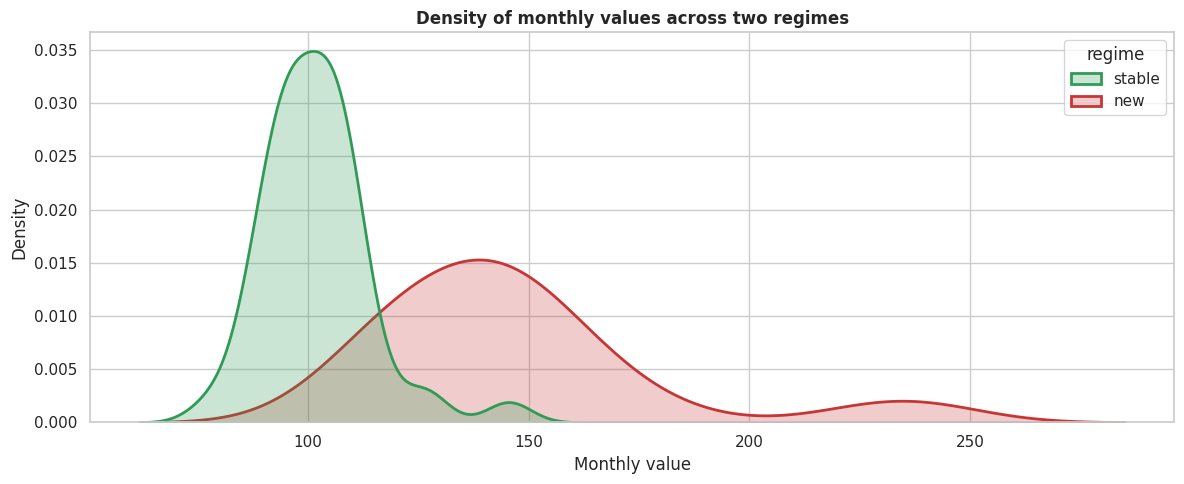

In [5]:
plt.figure(figsize=(12, 5))

sns.kdeplot(data=df, x="value", hue="regime", palette=colors,
    fill=True, alpha=.25, linewidth=2, common_norm=False)

plt.title("Density of monthly values across two regimes", weight="bold")
plt.xlabel("Monthly value")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

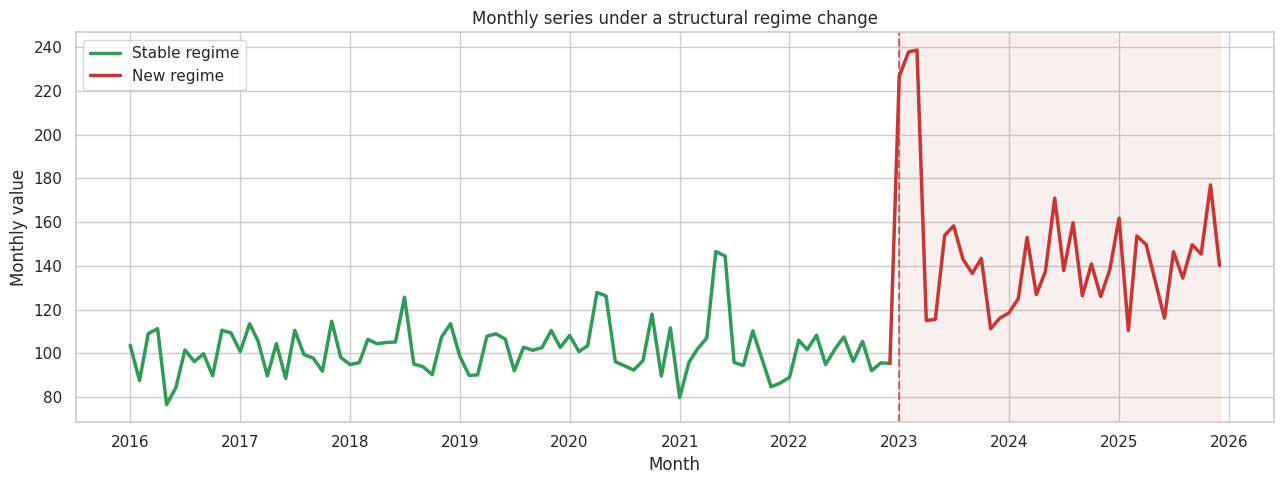

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.axvspan(y.index[cut], y.index[-1], color="#c73535", alpha=.08)
ax.axvline(y.index[cut], color="#c73535", linestyle="--", alpha=.7)
ax.plot(y.iloc[:cut], color=colors["stable"], linewidth=2.5, label="Stable regime")
ax.plot(y.iloc[cut - 1:], color=colors["new"], linewidth=2.5, label="New regime")

ax.set(title="Monthly series under a structural regime change",xlabel="Month",
       ylabel="Monthly value")
ax.legend()
plt.tight_layout()
plt.show()

# Statiscal testing

In [12]:
y = df.set_index("month")["value"]
y = y.asfreq("MS")

adf_stat, adf_pvalue, adf_lags,*_ = adfuller(y, autolag="AIC")
kpss_stat, kpss_pvalue, kpss_lags, _ = kpss(y, regression="c", nlags="auto")

print("CLASSICAL STATIONARITY DIAGNOSTICS\n")

print(f"ADF statistic: {adf_stat:.3f} | p-value: {adf_pvalue:.3f} | lags: {adf_lags}")

print(f"\nKPSS statistic: {kpss_stat:.3f} | p-value: {kpss_pvalue:.3f} | lags: {kpss_lags}")

# ADF
# H₀: shocks persist so the series does not reliably return to a stable level
# H₁: shocks fade and the series behaves around a stable level

# KPSS
# H₀: the series fluctuates around a stable level
# H₁: the level is not stable over time

CLASSICAL STATIONARITY DIAGNOSTICS

ADF statistic: -2.724 | p-value: 0.070 | lags: 3

KPSS statistic: 1.249 | p-value: 0.010 | lags: 5


In [13]:
za_stat, za_pvalue, _, za_lags, za_break = zivot_andrews(y, regression="ct")

print("ZIVOT-ANDREWS DIAGNOSTIC\n")
print(f"Test statistic: {za_stat:.3f} | p-value: {za_pvalue:.3f} | lags: {za_lags}")
print(f"Estimated break date: {y.index[za_break].strftime('%B %Y')}")

# H₀: the series accumulates shocks and it does not return to stable, without a structural break
# H₁: the series is stable around a level that changes once at an estimated break date

ZIVOT-ANDREWS DIAGNOSTIC

Test statistic: -8.313 | p-value: 0.001 | lags: 3
Estimated break date: December 2022


In [14]:
y = df.set_index("month")["value"]

model = MarkovRegression(y, k_regimes=2, trend="c", switching_variance=True)

# Markov Switching infers latent regimes with different means and variances
# Start values only stabilize the optimizer; all final parameters are estimated

fit = MarkovRegression(y, k_regimes=2, trend="c", switching_variance=True).fit(
    start_params=[.98, .02, *np.quantile(y, [.25, .75]), y.var() / 4, y.var()],
    method="lbfgs", maxiter=500, em_iter=0, cov_type="robust", disp=False,)

print(fit.summary())

                        Markov Switching Model Results                        
Dep. Variable:                  value   No. Observations:                  120
Model:               MarkovRegression   Log Likelihood                -501.048
Date:                Wed, 30 Sep 2026   AIC                           1014.096
Time:                        08:11:26   BIC                           1030.821
Sample:                    01-01-2016   HQIC                          1020.888
                         - 12-01-2025                                         
Covariance Type:               robust                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        100.6467      1.104     91.145      0.000      98.482     102.811
sigma2        94.3259     17.353      5.436      0.0

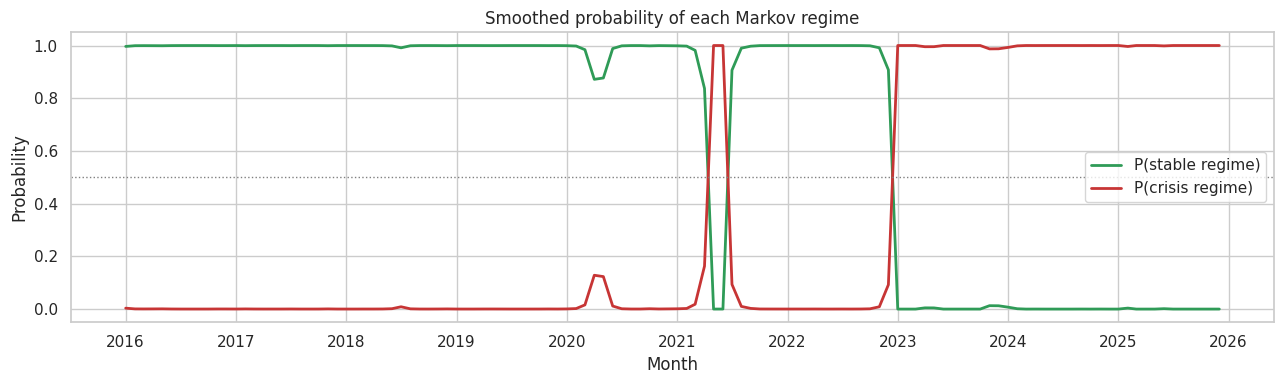

In [15]:
probs = np.asarray(fit.smoothed_marginal_probabilities)

plt.figure(figsize=(13, 4))

plt.plot(y.index, probs[:, 0], color="#2f9b57", linewidth=2, label="P(stable regime)")
plt.plot(y.index, probs[:, 1], color="#c73535", linewidth=2, label="P(crisis regime)")
plt.axhline(.5, color="gray", linestyle=":", linewidth=1)

plt.title("Smoothed probability of each Markov regime")
plt.xlabel("Month")
plt.ylabel("Probability")
plt.ylim(-.05, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# Comparing modeling alternatives

In [18]:
# ____________ Train/Test split _____________________________
# stable history for training while new regime for testing
train = y.iloc[:cut].asfreq('MS')
test = y.iloc[cut:].asfreq('MS')
horizon = len(test)
#___________________________________________________________

#_____________ Model training ________________________________________________________________
# Recursirve forecasting is a method in which each prediction is feeded into the next forecast step.
linear = ForecasterRecursive(LinearRegression(), lags=12); linear.fit(y=train)

xgb = ForecasterRecursive(
    XGBRegressor(n_estimators=150, max_depth=2, learning_rate=.05,
        objective="reg:squarederror", random_state=42 ),lags=12); xgb.fit(y=train)

# ________________ Inference on test set ___________________________________________
# Naive forecasting is predicting in the next step the exact past value
naive_pred = pd.Series(train.iloc[-1], index=test.index)

# Classical linear regression model
linear_pred = linear.predict(steps=horizon)

# XGboost regressor as the non-linear tree based model
xgb_pred = xgb.predict(steps=horizon)

In [ ]:
# Chronos Mini is a pretrained foundation model used here in zero-shot mode

chronos = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-mini",
    device_map="cuda",
    dtype=torch.float16,)

forecast = chronos.predict(
    inputs=torch.tensor(train.to_numpy(), dtype=torch.float32),
    prediction_length=horizon,
    num_samples=50,)

chronos_pred = forecast[0].median(dim=0).values.float().cpu().numpy()

# Evaluating perfomance

In [20]:
predictions = {
    "Naive": naive_pred,
    "Linear": linear_pred,
    "XGBoost": xgb_pred,
    "Chronos": chronos_pred}

print("FORECASTING BENCHMARK\n")
print(f"{'Model':<10} {'R²':>8} {'MAE':>10} {'RMSE':>10}")
print("-" * 42)

for name, pred in predictions.items():
    pred = np.asarray(pred).ravel()
    print(
        f"{name:<10} "
        f"{r2_score(test, pred):>8.3f} "
        f"{mean_absolute_error(test, pred):>10.2f} "
        f"{mean_squared_error(test, pred) ** .5:>10.2f}")

FORECASTING BENCHMARK

Model            R²        MAE       RMSE
------------------------------------------
Naive        -2.682      51.12      59.89
Linear       -1.932      43.84      53.44
XGBoost      -1.927      43.40      53.40
Chronos      -2.309      47.33      56.78


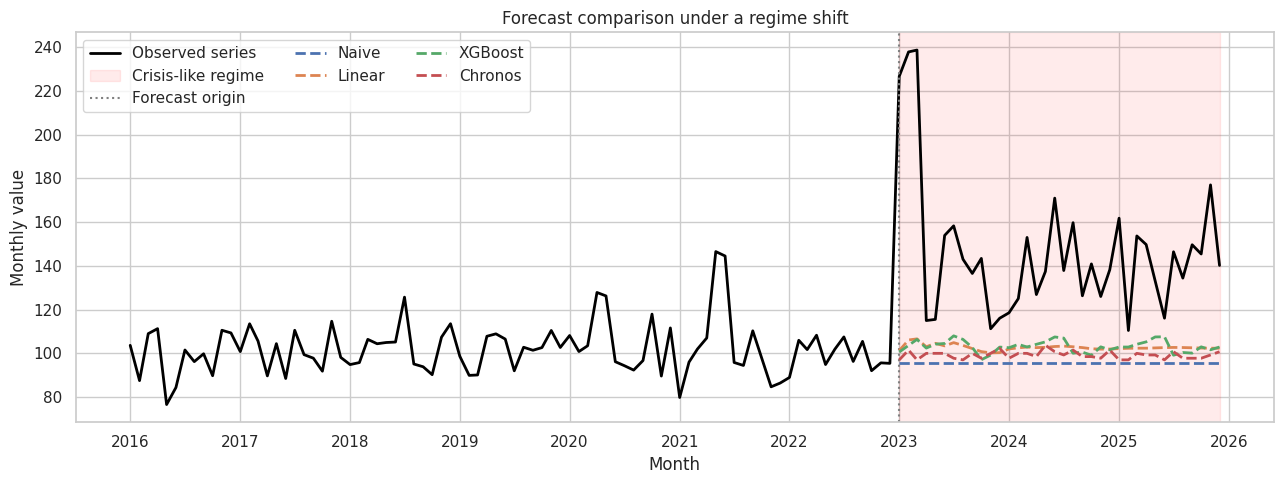

In [21]:
plt.figure(figsize=(13, 5))

plt.plot(y, color="black", linewidth=2, label="Observed series")

# Crisis / evaluation regime
plt.axvspan(test.index[0],test.index[-1],color="red",
            alpha=0.08,label="Crisis-like regime")

plt.axvline(test.index[0], color="gray", linestyle=":", label="Forecast origin")

for name, pred in predictions.items():
    plt.plot(test.index, np.asarray(pred).ravel(), "--", linewidth=2, label=name)

plt.title("Forecast comparison under a regime shift")
plt.xlabel("Month")
plt.ylabel("Monthly value")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()